# <a id='toc1_'></a>[PLOTS OF EACH VARIABLE](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [PLOTS OF EACH VARIABLE](#toc1_)    
    - [Import and setup](#toc1_1_1_)    
  - [Upload of dataset](#toc1_2_)    
  - [Plotting for clearance](#toc1_3_)    
  - [First attempt - plot of one variable](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

### <a id='toc1_1_1_'></a>[Import and setup](#toc0_)

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import src.utils as utils
import pandas as pd
import matplotlib.pyplot as plt

UNUSABLE = [
    "Rural population living in areas where elevation is below 5 meters (% of total population)",
    "Access to electricity, rural (% of rural population)",
    "Surface area (sq. km)",
    "Rural land area (sq. km)",
    "Land area (sq. km)",
    "Average precipitation in depth (mm per year)",
    "Agricultural irrigated land (% of total agricultural land)",
    "Rural land area where elevation is below 5 meters (% of total land area)",
    "Rural land area where elevation is below 5 meters (sq. km)"
]

## <a id='toc1_2_'></a>[Upload of dataset](#toc0_)

In [2]:
df = utils.load_data()

Dataset caricato: 65 anni, 28 variabili.


## <a id='toc1_3_'></a>[Plotting for clearance](#toc0_)

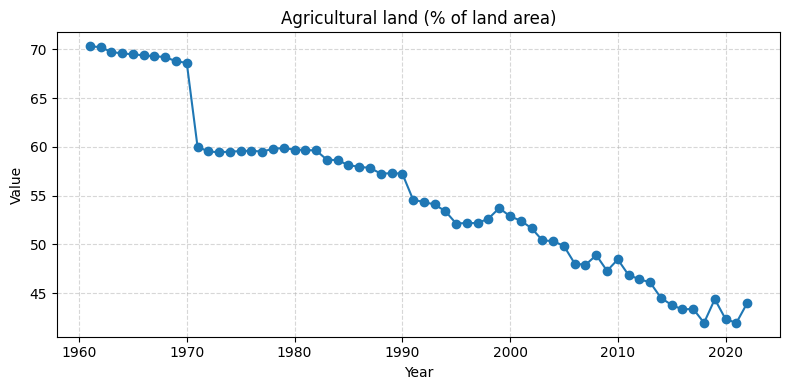

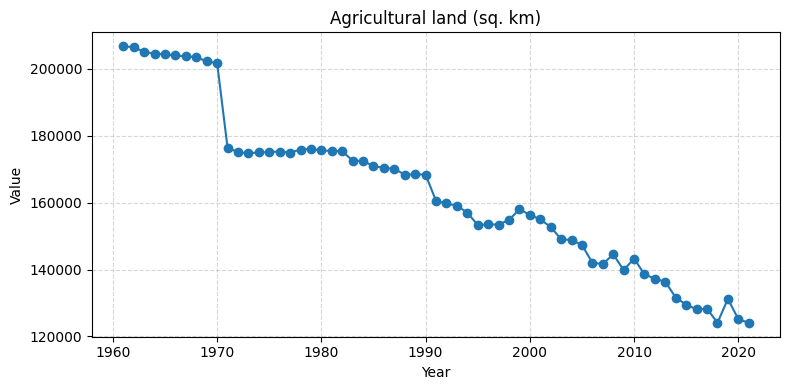

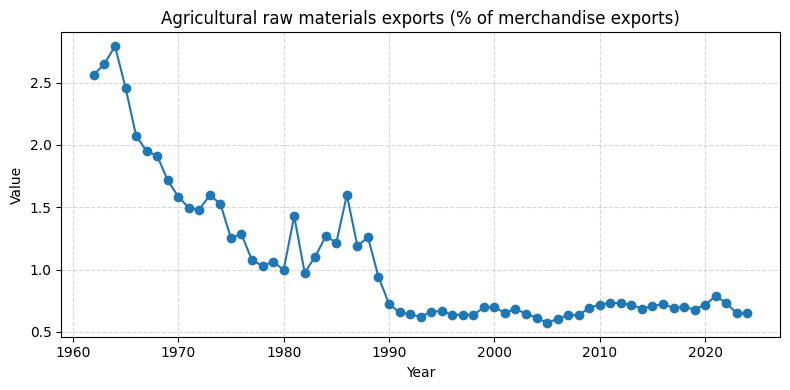

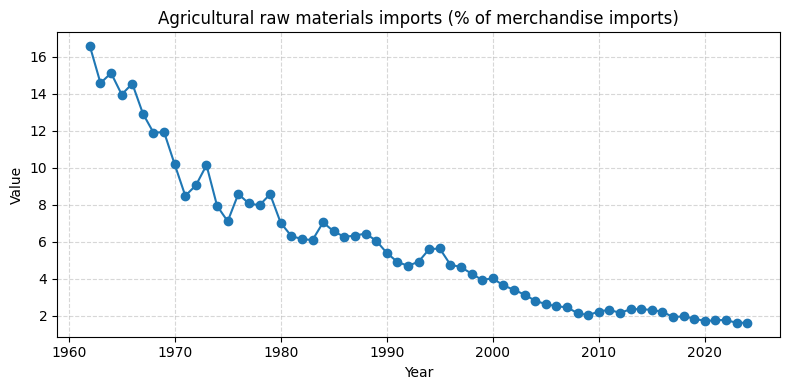

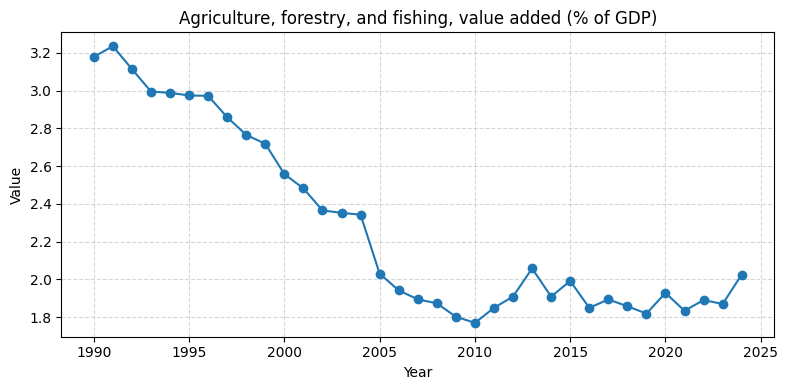

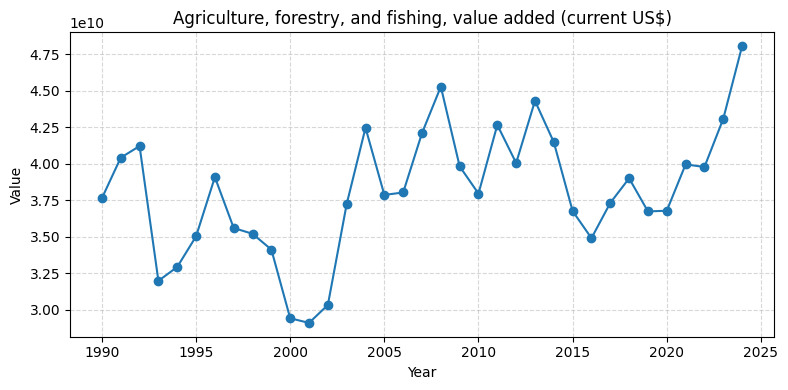

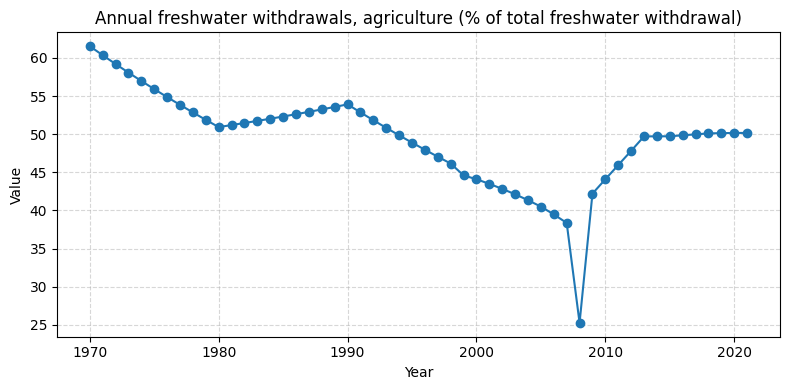

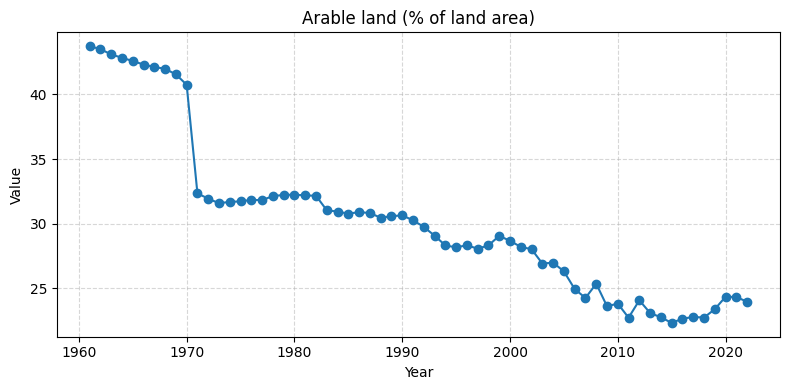

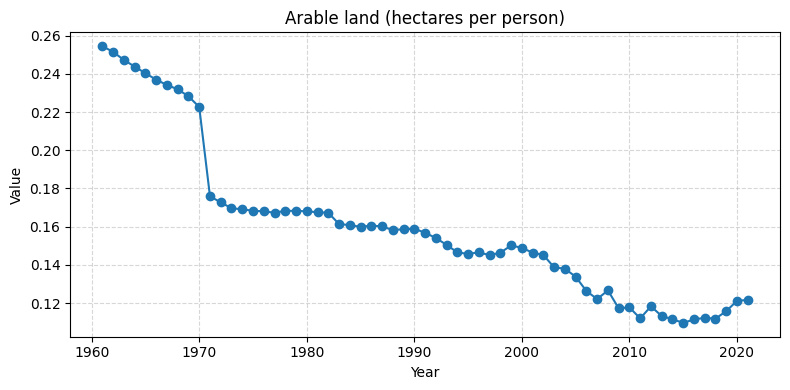

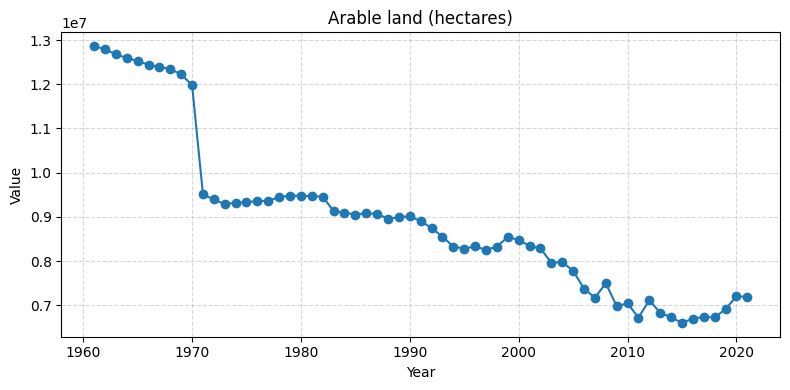

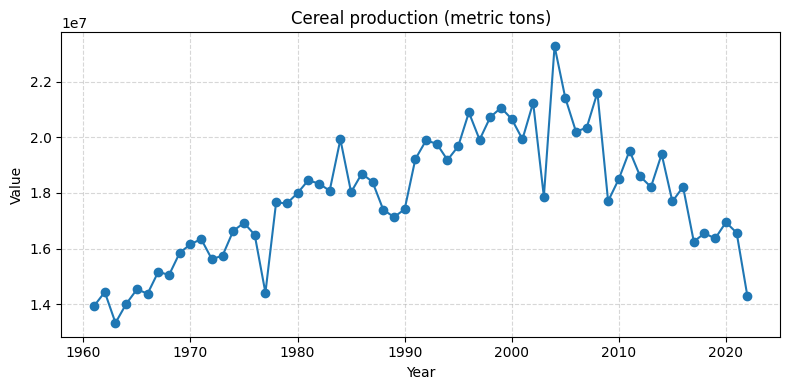

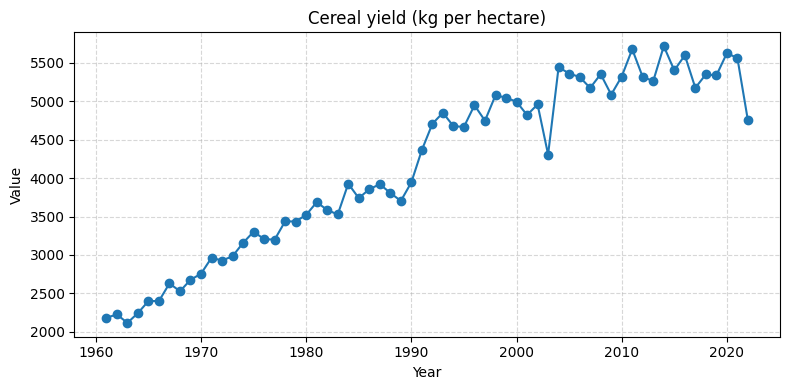

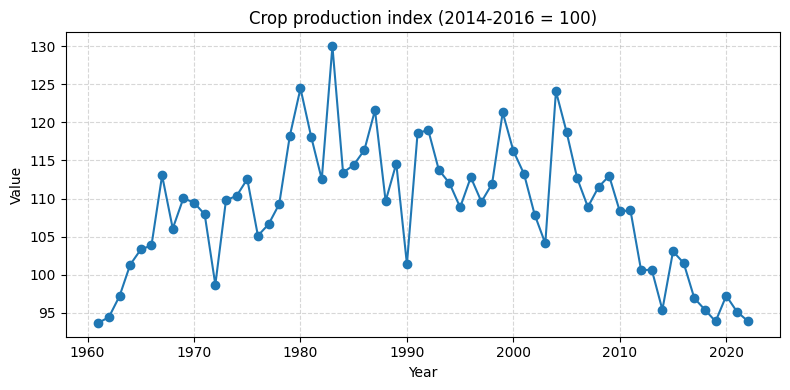

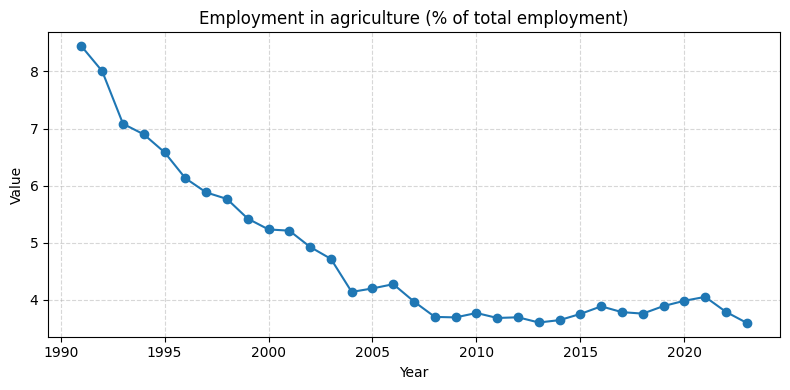

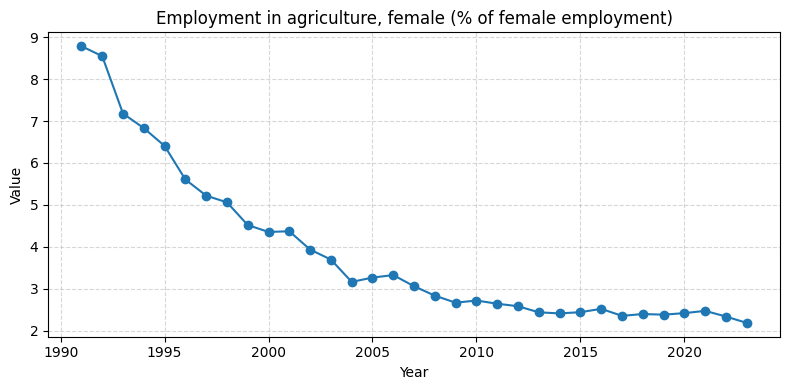

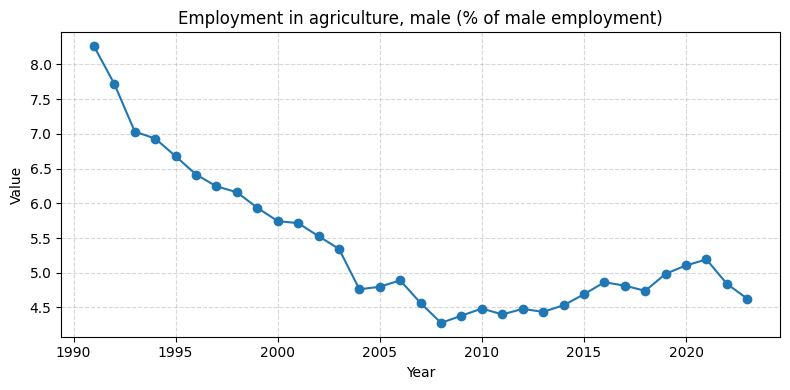

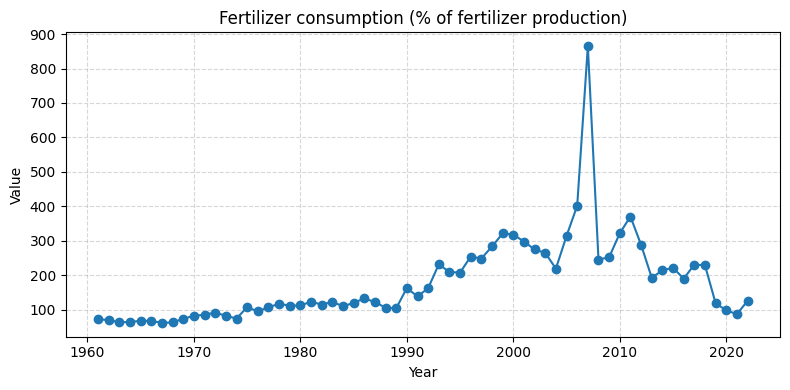

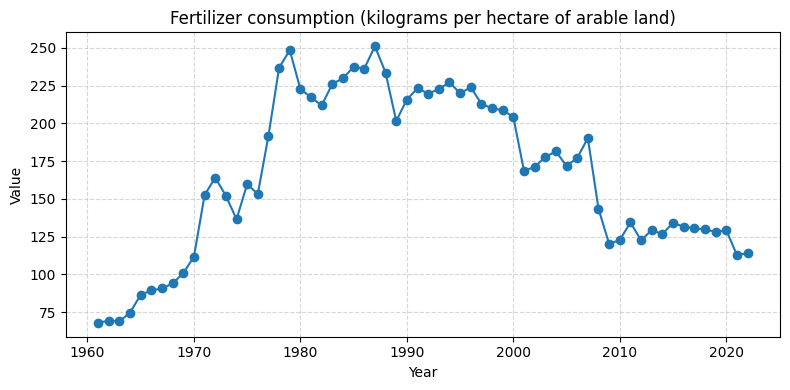

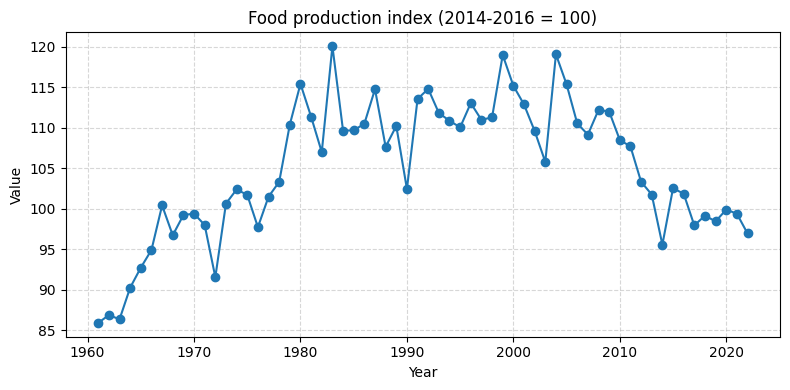

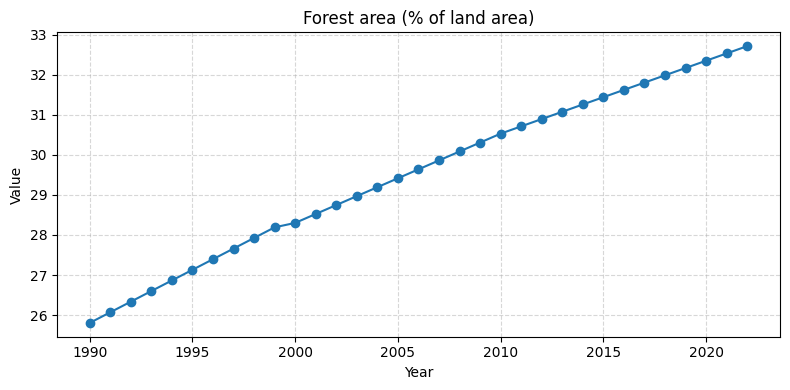

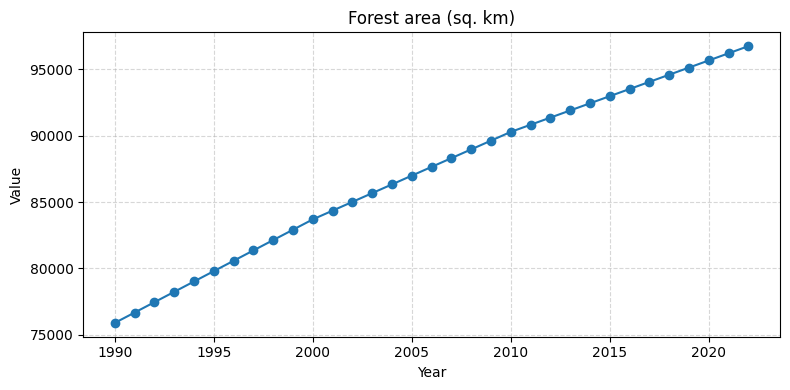

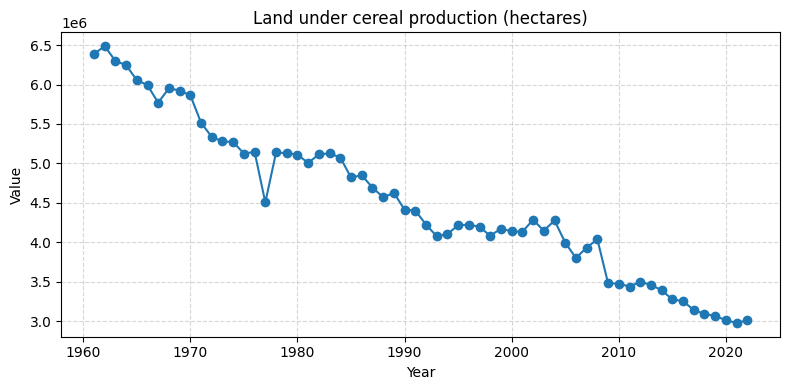

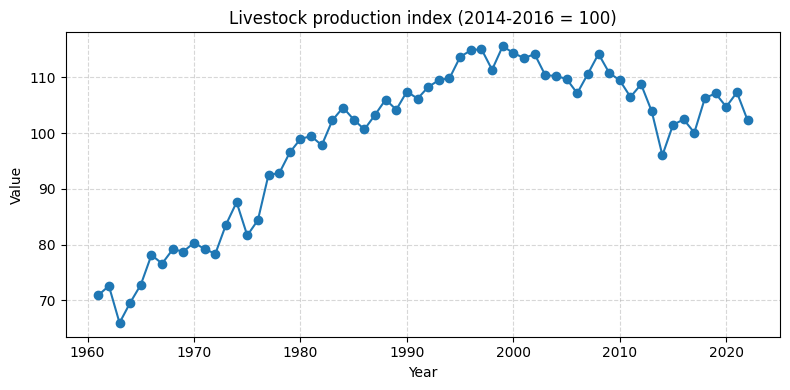

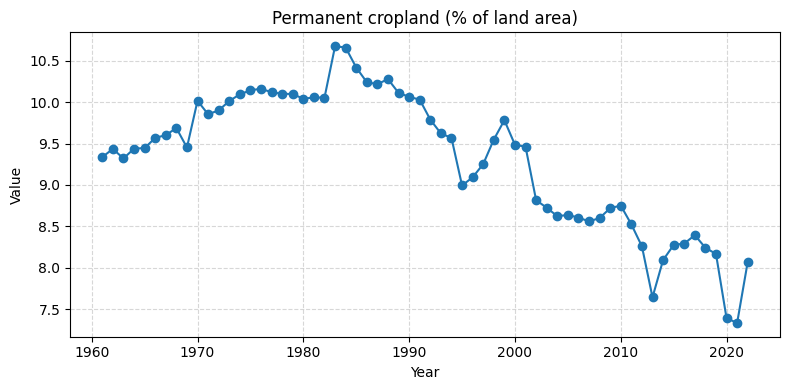

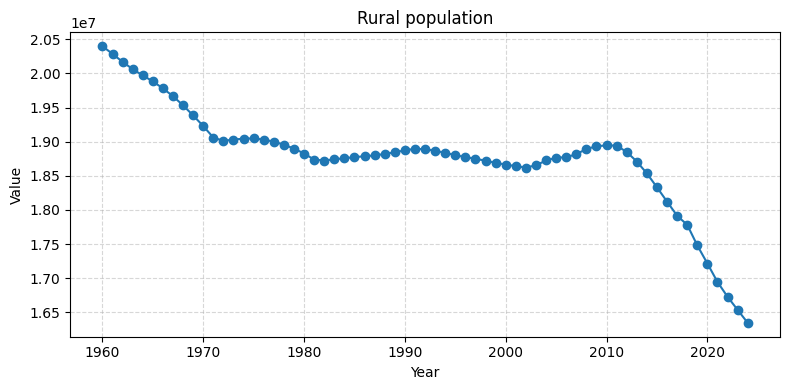

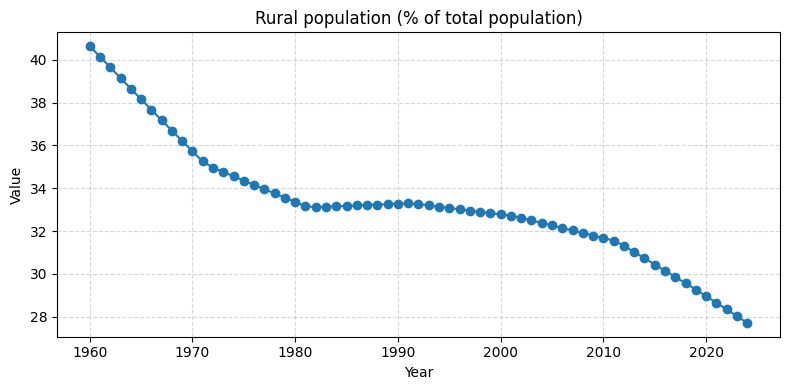

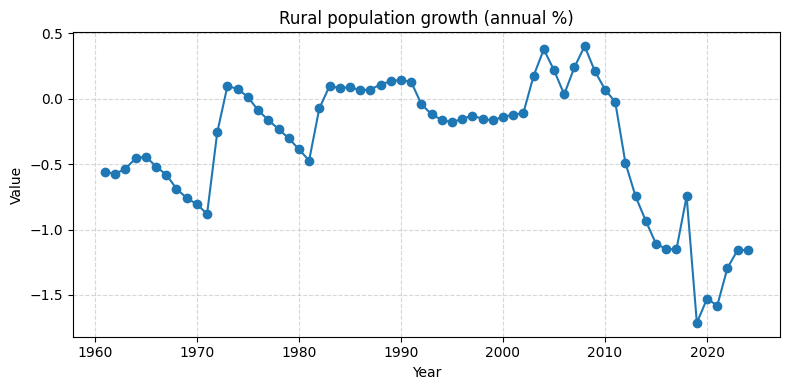

In [4]:
x = df['Year'] if 'Year' in df.columns else df.index

# seleziona solo colonne numeriche e rimuovi 'Year' e quelle in UNUSABLE
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
plot_cols = [c for c in numeric_cols if c != 'Year' and c not in UNUSABLE]

for col in plot_cols:
    if df[col].dropna().empty:
        continue

    plt.figure(figsize=(8, 4))
    plt.plot(x, df[col], marker='o', linestyle='-')
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## <a id='toc1_4_'></a>[First attempt - plot of one variable](#toc0_)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

            value
NaT          4.00
NaT          1.00
1960-01-01    NaN
1961-01-01  70.91
1962-01-01  72.59


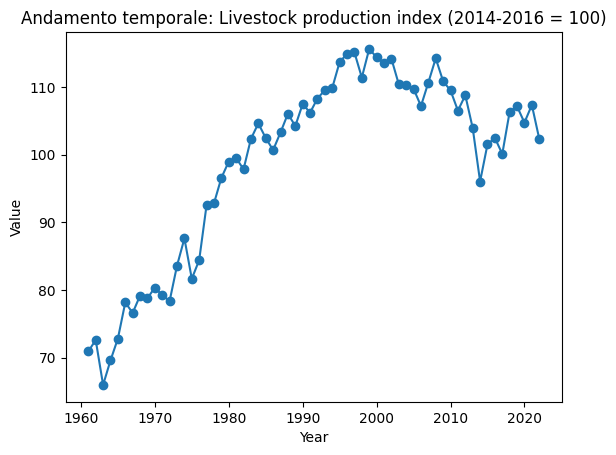

In [6]:
df = pd.read_excel("../COPY_rural_development_dataset.xlsx", sheet_name="Data")

proxy_name = "Livestock production index (2014-2016 = 100)"
country_name = "Italy"

row = df[(df['Indicator Name'] == proxy_name) & (df['Country Name'] == country_name)]

# Seleziona solo le colonne numeriche (anni)
values = row.select_dtypes(include=['number']).T
values.columns = ['value']

# Se ci sono intestazioni di anni come stringhe, le convertiamo in numeri o date
values.index = pd.to_datetime(values.index, errors='coerce', format='%Y')
print(values.head())

plt.plot(values.index, values['value'], marker='o')
plt.title(f"Andamento temporale: {proxy_name}")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()